## Notebook 4: Probability Calibration & Threshold Optimization


Traditional classification models often use a default decision threshold of 0.50 to separate positive and negative predictions. However, in credit risk modeling, the costs associated with lending decisions are rarely symmetric.

The objective of this notebook is to evaluate probability estimates produced by the selected baseline model, assess their calibration quality, and identify an optimal decision threshold using business-driven considerations.

Rather than maximizing accuracy, the goal is to determine a threshold that balances risk detection, false approvals, and operational efficiency.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.calibration import CalibratedClassifierCV,calibration_curve
from sklearn.metrics import(
    accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,
    classification_report,average_precision_score,roc_auc_score,brier_score_loss
)

## Load Model and Evaluation Data

Load the selected baseline model and processed testing dataset from previous notebooks.

The probability estimates generated in this notebook will serve as the foundation for business decision-making in later stages of RiskLens.

In [ ]:
x_train=pd.read_csv("x_train_processed.csv")
x_test=pd.read_csv("x_test_processed.csv")
y_train=pd.read_csv("y_train.csv").squeeze()
y_test=pd.read_csv("y_test.csv").squeeze()

best_model=joblib.load("best_baseline_model.pkl")

## Generate Default Probabilities

Unlike class predictions, probability estimates provide a measure of confidence regarding a potential default.

These probabilities enable threshold optimization, risk segmentation, and explainable lending decisions.

In [ ]:
y_proba=best_model.predict_proba(x_test)[:,1]
y_proba[:10]

array([0.04729249, 0.03637318, 0.05895396, 0.12535161, 0.08177067,
       0.02158387, 0.30278365, 0.07618759, 0.24721703, 0.14755223])

## Probability Distribution Analysis

Visualize the distribution of predicted default probabilities.

This helps assess how confidently the model separates low-risk and high-risk applicants.

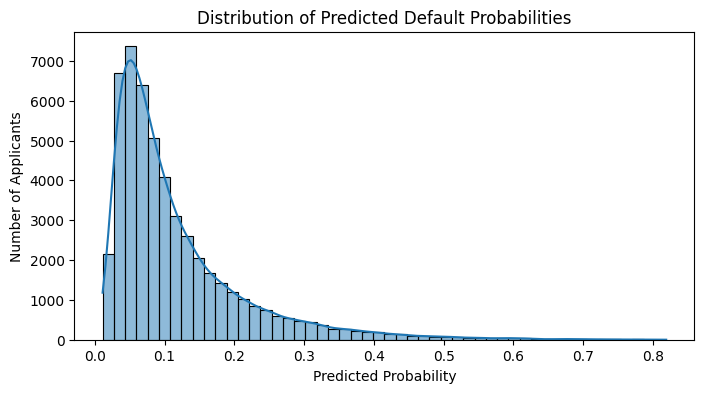

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(
    y_proba,
    bins=50,
    kde=True
)
plt.title("Distribution of Predicted Default Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Applicants")
plt.show()

# Baseline Threshold 0.5

In [ ]:
threshold=0.5

y_pred_50=(y_proba>=threshold).astype(int)
print("Accuracy:",accuracy_score(y_test,y_pred_50))
print("Precision:",precision_score(y_test,y_pred_50))
print("Recall:",recall_score(y_test,y_pred_50))
print("F1 Score:",f1_score(y_test,y_pred_50))
print("ROC-AUC:",roc_auc_score(y_test,y_proba))
print("PR-AUC:",average_precision_score(y_test,y_proba))

Accuracy: 0.8861758370863521
Precision: 0.6260683760683761
Recall: 0.049401450008430284
F1 Score: 0.09157680887638693
ROC-AUC: 0.7580078402160226
PR-AUC: 0.3291695187433482


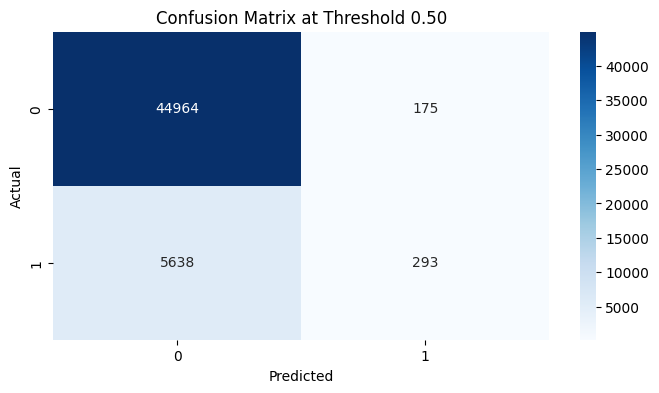

In [ ]:
cm=confusion_matrix(y_test,y_pred_50)
plt.figure(figsize=(8,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix at Threshold 0.50")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Finding: The Default 0.50 Threshold Is Not Suitable

Although the model achieves strong overall accuracy at a threshold of 0.50, recall remains extremely low. This means a large number of actual defaulters are incorrectly classified as safe applicants.

For credit risk applications, missed defaulters represent potential financial loss. This observation confirms that the traditional 0.50 threshold is too conservative for RiskLens and motivates a business-driven threshold search.

## Threshold Optimization

Classification thresholds determine how predicted probabilities are converted into lending decisions.

Rather than accepting the default threshold of 0.50, multiple candidate thresholds are evaluated to understand their impact on:

- Accuracy
- Precision
- Recall
- F1 Score

This analysis helps identify the threshold that best aligns with business objectives.

# Threshold Sweep

In [ ]:
thresholds=np.arange(0.10,0.91,0.05)
threshold_result=[]

for threshold in thresholds :
  y_pred= (y_proba>=threshold).astype(int)

  threshold_result.append({
      "Threshold":threshold,
      "Accuracy":accuracy_score(y_test,y_pred),
      "Precision":precision_score(y_test,y_pred,zero_division=0),
      "Recall":recall_score(y_test,y_pred,zero_division=0),
      "F1 Score":f1_score(y_test,y_pred,zero_division=0),

  })
threshold_result_df=pd.DataFrame(threshold_result)
threshold_result_df




,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.641649,0.208667,0.746923,0.326203
1,0.15,0.773644,0.271865,0.565503,0.367199
2,0.20,0.832407,0.327242,0.419659,0.367733
3,0.25,0.861093,0.378728,0.306188,0.338616
4,0.30,0.875426,0.429414,0.221042,0.291852
5,0.35,0.882808,0.486054,0.158658,0.239227
6,0.40,0.885686,0.538335,0.110099,0.182811
7,0.45,0.886646,0.595430,0.074692,0.132734
8,0.50,0.886176,0.626068,0.049401,0.091577
9,0.55,0.885686,0.664311,0.031698,0.060509


### Finding: Model Performance Changes Dramatically Across Thresholds

Lower thresholds increase the model's ability to detect actual defaulters but also increase false positives. Higher thresholds improve precision but miss a larger proportion of risky applicants.

The results demonstrate that threshold selection is a business decision rather than a purely statistical one.

## Threshold Trade-Off Analysis

Visualize the relationship between threshold values and key evaluation metrics.

The goal is to identify a threshold that balances business objectives and predictive performance.

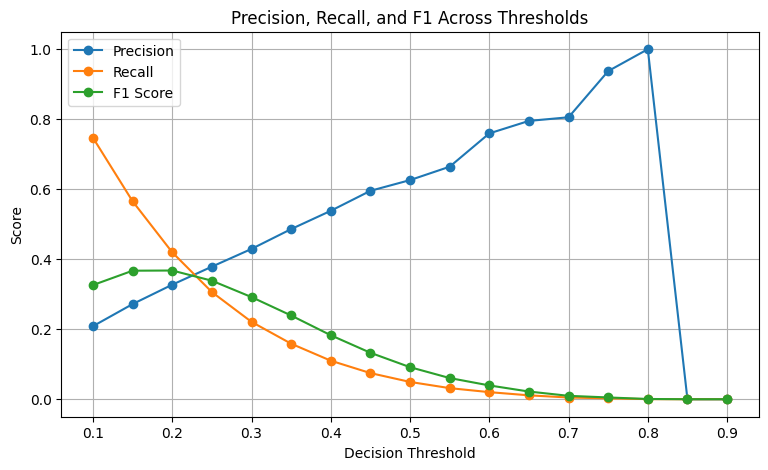

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(threshold_result_df["Threshold"], threshold_result_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_result_df["Threshold"], threshold_result_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_result_df["Threshold"], threshold_result_df["F1 Score"], marker="o", label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

## Business Cost Optimization

Not all prediction errors have the same financial impact.

In credit risk assessment:

- Approving a future defaulter may result in substantial financial losses.
- Rejecting a safe applicant may result in lost business opportunities.

A custom cost function is introduced to quantify these tradeoffs and identify the threshold that minimizes expected business cost.

In [ ]:
false_negative_cost= 100000
false_positive_cost= 20000

In [ ]:
cost_results=[]

for threshold in thresholds:
  y_pred=(y_proba>=threshold).astype(int)
  tn,fp,fn,tp= confusion_matrix(y_test,y_pred).ravel()

  total_cost=(false_negative_cost*fn) + (false_positive_cost*fp)

  cost_results.append({
      "Threshold": threshold,
      "TN":tn,
      "FP":fp,
      "FN":fn,
      "TP":tp,
      "Total Cost":total_cost
  })

cost_results_df=pd.DataFrame(cost_results)
cost_results_df


,Threshold,TN,FP,FN,TP,Total Cost
0,0.10,28339,16800,1501,4430,486100000
1,0.15,36156,8983,2577,3354,437360000
2,0.20,40022,5117,3442,2489,446540000
3,0.25,42160,2979,4115,1816,471080000
4,0.30,43397,1742,4620,1311,496840000
5,0.35,44144,995,4990,941,518900000
6,0.40,44579,560,5278,653,539000000
7,0.45,44838,301,5488,443,554820000
8,0.50,44964,175,5638,293,567300000
9,0.55,45044,95,5743,188,576200000


## Identify Optimal Threshold

Select the threshold that minimizes business cost while maintaining acceptable predictive performance.

This threshold will serve as the decision boundary for all subsequent risk segmentation and lending decisions.

In [ ]:
best_threshold_row= cost_results_df.loc[cost_results_df["Total Cost"].idxmin()]
best_threshold_row

,1
Threshold,1.500000e-01
TN,3.615600e+04
FP,8.983000e+03
FN,2.577000e+03
TP,3.354000e+03
Total Cost,4.373600e+08


In [ ]:
best_threshold=best_threshold_row["Threshold"]
y_pred_best=(y_proba>=best_threshold).astype(int)
print("Best Business Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best Business Threshold: 0.15000000000000002
Accuracy: 0.7736440180144899
Precision: 0.2718651211801897
Recall: 0.5655032878098128
F1 Score: 0.36719947449091306

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.57      0.37      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070



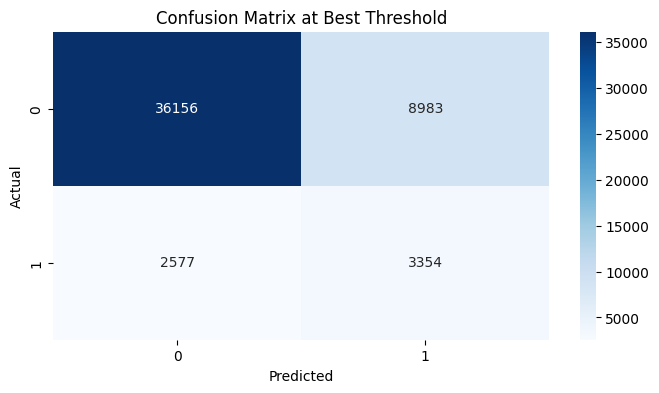

In [ ]:
cm=confusion_matrix(y_test,y_pred_best)
plt.figure(figsize=(8,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix at Best Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

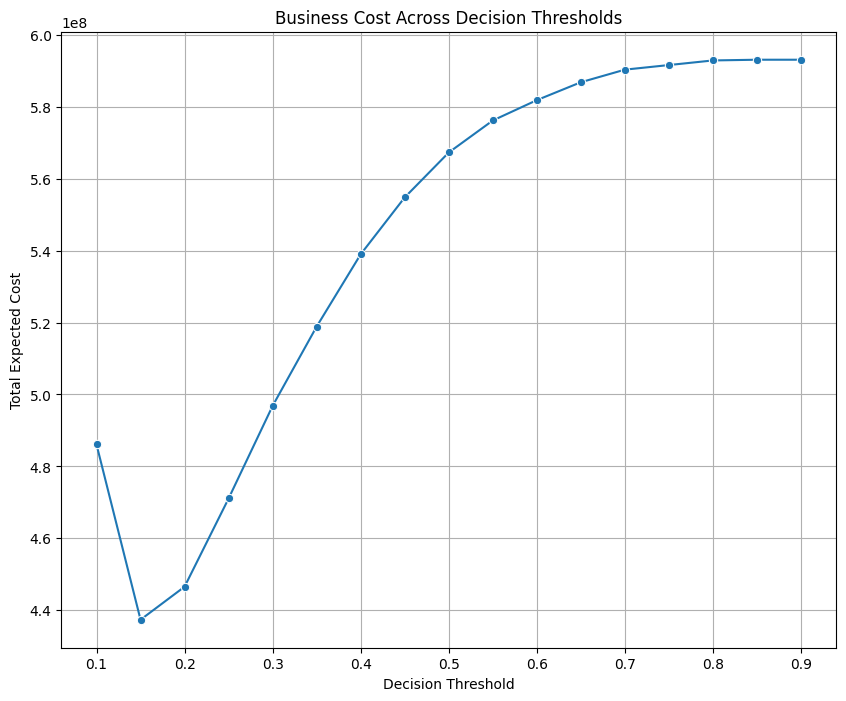

In [ ]:
plt.figure(figsize=(10,8))
sns.lineplot(
    data=cost_results_df,
    x="Threshold",
    y="Total Cost",
    marker="o"
)

plt.title("Business Cost Across Decision Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Expected Cost")
plt.grid(True)
plt.show()

### Finding: Business-Optimal Threshold = 0.15

Cost-based analysis selected **0.15** as the optimal decision threshold.

This means applicants with predicted default probability above 15% should no longer be treated as automatically safe. Instead, they require stricter risk handling in the decision engine.

This threshold becomes the foundation for Notebook 5, where probabilities are converted into risk bands and lending decisions.

## Probability Calibration Assessment

A model may achieve strong classification performance while producing poorly calibrated probabilities.

Calibration analysis evaluates whether predicted probabilities accurately reflect observed default rates.

In [ ]:
from sklearn.calibration import calibration_curve

prob_true,prob_pred=calibration_curve(
    y_test,
    y_proba,
    n_bins=10
  )

## Probability Calibration

Since RiskLens uses predicted probabilities for decision-making, those probabilities must be reasonably reliable.

Calibration analysis checks whether predicted default probabilities align with actual observed default rates.

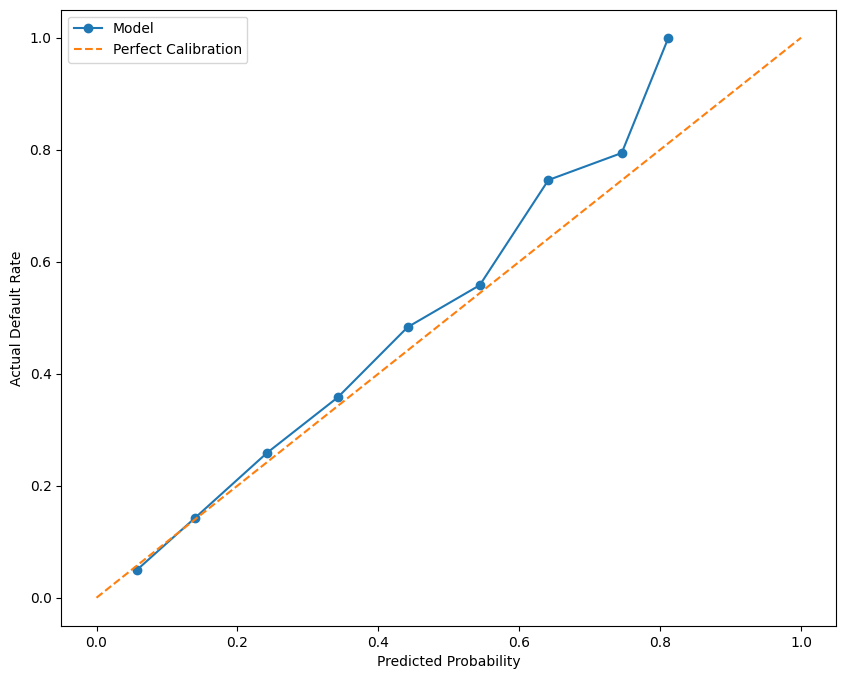

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label="Model"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.legend()
plt.show()


In [ ]:
brier_score=brier_score_loss(y_test,y_proba)
print(f"Brier Score:{brier_score:.4f}")

Brier Score:0.0909


### Finding: Probability Estimates Are Reasonably Reliable

The calibration curve generally follows the ideal calibration line, indicating that higher predicted probabilities correspond to higher observed default rates.

The model achieved a Brier Score of approximately 0.0909. Since lower Brier Scores indicate better probability accuracy and a score of 0 represents perfect calibration, this result suggests that the model produces reasonably reliable probability estimates.

While minor calibration deviations remain, the probability quality is sufficiently strong to support threshold optimization, risk segmentation, and downstream lending decisions.

## Persist Business Threshold

Save the selected threshold for reuse in the decision engine developed in the next notebook.

In [ ]:
threshold_result_df.to_csv("threshold_metrics_result.csv",index=False)
cost_results_df.to_csv("threshold_cost_result.csv",index=False)

best_threshold=best_threshold_row["Threshold"]
joblib.dump(best_threshold,"best_business_threshold.pkl")

best_threshold

np.float64(0.15000000000000002)

## Key Findings

- The conventional 0.50 threshold produced high accuracy but failed to identify enough actual defaulters.
- Threshold analysis revealed a substantial precision-recall trade-off across different decision boundaries.
- Cost-based optimization selected 0.15 as the business-optimal threshold.
- Probability calibration analysis showed that predicted default probabilities generally align with observed outcomes.
- A Brier Score of approximately 0.0909 indicates reasonably reliable probability estimates.
- The selected threshold will be used in Notebook 5 to transform probabilities into risk bands, lending decisions, and applicant recommendations.

RiskLens now moves beyond model evaluation and begins translating probability estimates into actionable business decisions.